In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Jury selection in Alameda County

In [2]:
jury = Table().with_columns(
    'ethnicity', make_array('asian', 'black', 'latino', 'white', 'other'),
    'eligible', make_array (.15, .18, .12, .54, .01),
    'panel', make_array(.26, .08, .08, .54, .04)
)
jury

ethnicity,eligible,panel
asian,0.15,0.26
black,0.18,0.08
latino,0.12,0.08
white,0.54,0.54
other,0.01,0.04


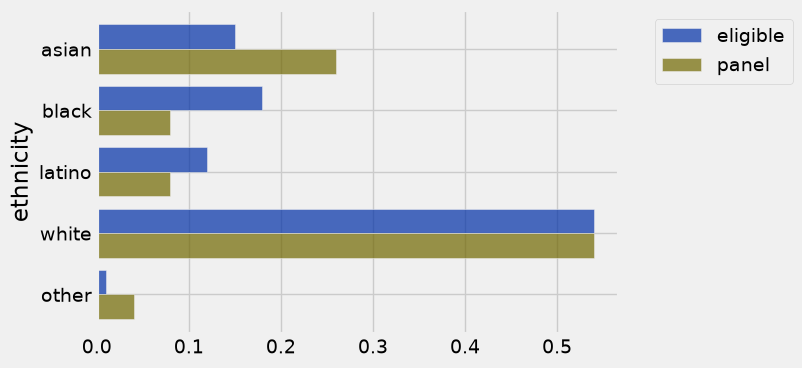

In [3]:
jury.barh('ethnicity')

In [4]:
model = make_array(.15, .18, .12, .54, .01)

In [5]:
simulated = sample_proportions(1453, model)
simulated

array([ 0.14865795,  0.18444597,  0.11355816,  0.54232622,  0.0110117 ])

In [6]:
jury_with_simulated = jury.with_column('simulated', simulated)
jury_with_simulated

ethnicity,eligible,panel,simulated
asian,0.15,0.26,0.148658
black,0.18,0.08,0.184446
latino,0.12,0.08,0.113558
white,0.54,0.54,0.542326
other,0.01,0.04,0.0110117


## We need a statistic

In [7]:
diffs = jury.column('panel')- jury.column('eligible')
jury_with_difference = jury.with_column('difference', diffs)
jury_with_difference

ethnicity,eligible,panel,difference
asian,0.15,0.26,0.11
black,0.18,0.08,-0.1
latino,0.12,0.08,-0.04
white,0.54,0.54,0
other,0.01,0.04,0.03


In [8]:
sum(jury_with_difference.column('difference'))

2.7755575615628914e-17

In [9]:
sum(jury_with_difference.where('difference', are.above(0)).column('difference'))

0.14000000000000001

In [10]:
sum(abs(jury_with_difference.column('difference'))) / 2

0.14000000000000001

## The total variation distance (TVD)

In [11]:
def tvd(dist1, dist2):
    return sum(abs(dist1-dist2)) / 2

In [12]:
obsvd_tvd = tvd(jury.column('panel'), jury.column('eligible'))
obsvd_tvd

0.14000000000000001

In [13]:
simulated_tvd = tvd(sample_proportions(1453, model), jury.column('eligible'))
simulated_tvd

0.024074328974535479

## model vs alternative viewpoint

In [14]:
def simulate_tvd():
    return tvd(sample_proportions(1453, model), model)

tvds = make_array()

num_simulations = 10000

for i in np.arange(num_simulations):
    new_tvd = simulate_tvd()
    tvds = np.append(tvds, new_tvd)

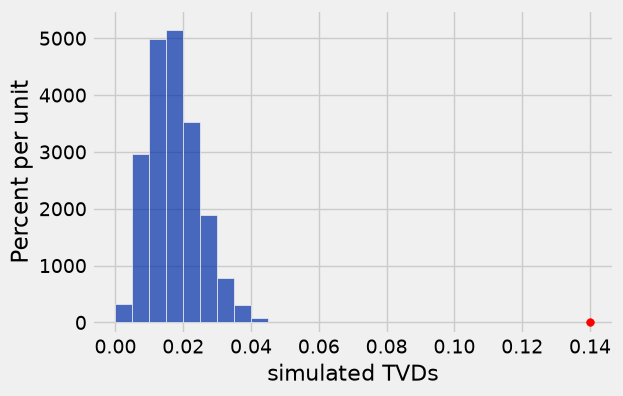

In [15]:
title = 'simulated TVDs'
bins = np.arange(0, .05, .005)

Table().with_columns(title, tvds).hist(bins = bins)

## plotting details
plt.ylim(-2, 55)
plt.scatter(obsvd_tvd, 0, color = 'red', s = 30)

# Hypothesis Testing with Numerical Data

In [19]:
scores = Table.read_table('scores_by_section.csv')
scores.show(5)

Section,Midterm
1,22
2,12
2,23
2,14
1,20


In [22]:
scores.group('Section').show()

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [26]:
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


In [42]:
section_3_average = scores.group('Section', np.average).column('Midterm average').item(2)
section_3_average

13.666666666666666

In [28]:
random_section = scores.sample(27, with_replacement=False)
random_section

Section,Midterm
1,21
1,21
1,22
6,0
5,13
12,9
10,16
5,21
1,21
6,14


In [29]:
np.average(random_section.column('Midterm'))

15.185185185185185

In [32]:
## Create function for one random sample average
def one_sample_average():
    return np.average( scores.sample(27, with_replacement=False).column('Midterm'))

one_sample_average()

15.444444444444445

In [35]:
simulated_sample_averages = make_array()
for i in np.arange(10000):
    simulated_sample_averages = np.append(simulated_sample_averages, one_sample_average())

In [36]:
simulated_sample_averages

array([ 16.03703704,  15.66666667,  16.44444444, ...,  14.81481481,
        15.48148148,  16.96296296])

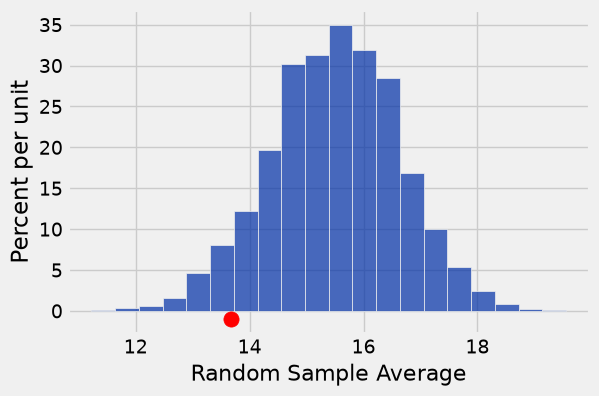

In [43]:
averages_table = Table().with_column('Random Sample Average', simulated_sample_averages)
averages_table.hist(bins = 20)
plt.scatter(section_3_average, -0.01, color='red', s=120)

### the tail first convention
- the area in the tail is less than 5%
- the result is "statistically significant"

## In a close call, calculate the p-value

**Task**:
- Calculate the proportion of sample averages which are equal to or "more extreme" than the observed section three average
- this is called p-value

In [44]:
section_3_average

13.666666666666666

In [45]:
simulated_sample_averages <= section_3_average

array([False, False, False, ..., False, False, False], dtype=bool)

In [47]:
np.count_nonzero(simulated_sample_averages <= section_3_average)

599

In [49]:
p_value = np.count_nonzero(simulated_sample_averages <= section_3_average)/10000
p_value

0.059900000000000002

**Task**: assume that our p-value cutoff is 0.05. Demarcate:
- the area of the simulated distribution that is lower than the section 3 average with a vertical line
- the area convered by the lowest 5% (the area to the left of the cutoff) 

In [50]:
simulation = 10000
five_percent_index = round(simulation * 0.05)
five_percent_index

500

In [51]:
sorted_averages = averages_table.sort(0).column(0)
sorted_averages

array([ 11.22222222,  11.33333333,  11.33333333, ...,  19.25925926,
        19.51851852,  19.55555556])

In [52]:
five_percent_point = sorted_averages.item(five_percent_index)
five_percent_point

13.592592592592593

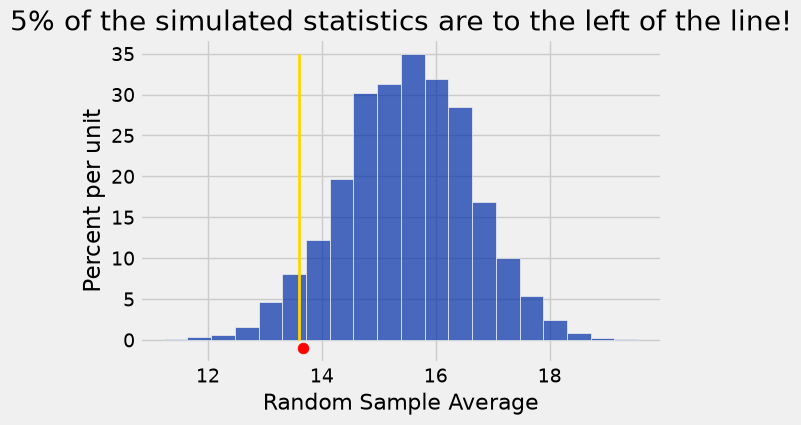

In [55]:
averages_table.hist(bins = 20)
plt.plot([five_percent_point, five_percent_point], [0, 0.35], color = 'gold', lw=2)
plt.title('5% of the simulated statistics are to the left of the line!')
plt.scatter(section_3_average, -0.01, color='red', s=60)

## P-Value
**The observed significance level**
The p-value is the chance:
- under the null hypothesis that the test statistic is equal to the value that was observed in the data or is even further in the direction of the alternative
  